In [302]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from src.profile_metrics import evaluate_profile_global, evaluate_profile_by_horizon

In [303]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [304]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_SDB_EL_Substation.parquet"
df_imputed = pd.read_parquet(path)

In [305]:
df_imputed.head()

,BU_TotActPwr_SDB_EL_Substation,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,dayofweek,is_weekend,hour,month,dayofmonth,minute_of_day,...,BU_TotActPwr_SDB_EL_Substation_roll_std_96,BU_TotActPwr_SDB_EL_Substation_trend_1_4,BU_TotActPwr_SDB_EL_Substation_trend_1_12,BU_TotActPwr_SDB_EL_Substation_trend_1_96,BU_TotActPwr_SDB_EL_Substation_trend_96_192,BU_TotActPwr_SDB_EL_Substation_yesterday_mean,BU_TotActPwr_SDB_EL_Substation_yesterday_max,BU_TotActPwr_SDB_EL_Substation_yesterday_midday_max,BU_TotActPwr_SDB_EL_Substation_yesterday_peak_time_step,BU_TotActPwr_SDB_EL_Substation_lastweek_same_day_peak
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-18 00:00:00,NaN,81.00000,143.00000,-1.73333,5,1,0,10,18,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-18 00:15:00,NaN,80.66667,143.00000,-1.50000,5,1,0,10,18,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-18 00:30:00,NaN,80.20000,142.66667,-1.73333,5,1,0,10,18,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-18 00:45:00,NaN,79.83333,141.66667,-2.16667,5,1,0,10,18,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-18 01:00:00,NaN,79.40000,140.33333,-3.13333,5,1,1,10,18,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [306]:
df_imputed.columns.tolist()

['BU_TotActPwr_SDB_EL_Substation',
 'BA_Soc',
 'PV_WS_AirTemp',
 'PV_WS_Radiation',
 'dayofweek',
 'is_weekend',
 'hour',
 'month',
 'dayofmonth',
 'minute_of_day',
 'sin_tod',
 'cos_tod',
 'sin_dow',
 'cos_dow',
 'is_business_hours',
 'is_midday_peak_window',
 'is_midday_weekday_peak',
 'slot_5min',
 'BU_TotActPwr_SDB_EL_Substation_lag_12',
 'BU_TotActPwr_SDB_EL_Substation_lag_24',
 'BU_TotActPwr_SDB_EL_Substation_lag_48',
 'BU_TotActPwr_SDB_EL_Substation_lag_96',
 'BU_TotActPwr_SDB_EL_Substation_lag_192',
 'BU_TotActPwr_SDB_EL_Substation_lag_288',
 'BU_TotActPwr_SDB_EL_Substation_roll_mean_24',
 'BU_TotActPwr_SDB_EL_Substation_roll_mean_48',
 'BU_TotActPwr_SDB_EL_Substation_roll_mean_96',
 'BU_TotActPwr_SDB_EL_Substation_roll_mean_288',
 'BU_TotActPwr_SDB_EL_Substation_roll_std_12',
 'BU_TotActPwr_SDB_EL_Substation_roll_std_24',
 'BU_TotActPwr_SDB_EL_Substation_roll_std_48',
 'BU_TotActPwr_SDB_EL_Substation_roll_std_96',
 'BU_TotActPwr_SDB_EL_Substation_trend_1_4',
 'BU_TotActPwr_SDB

In [307]:
df = df_imputed.sort_index().copy()

if not isinstance(df.index, pd.DatetimeIndex):
    raise ValueError("df must have a DatetimeIndex before using this TCN pipeline.")

target_col = "BU_TotActPwr_SDB_EL_Substation"

# All columns are used as input features.
# The target column is also included, because TCN needs past load values.
tcn_feature_cols = list(df.columns)

# Remove duplicates just in case
tcn_feature_cols = list(dict.fromkeys(tcn_feature_cols))

print("Target column:", target_col)
print("Number of TCN features:", len(tcn_feature_cols))
print("First 10 features:", tcn_feature_cols[:10])

Target column: BU_TotActPwr_SDB_EL_Substation
Number of TCN features: 41
First 10 features: ['BU_TotActPwr_SDB_EL_Substation', 'BA_Soc', 'PV_WS_AirTemp', 'PV_WS_Radiation', 'dayofweek', 'is_weekend', 'hour', 'month', 'dayofmonth', 'minute_of_day']


In [308]:
# target_col = "BU_TotActPwr_Academy"

# # All columns except target become input features
# feature_cols = [c for c in df_imputed.columns if c != target_col]

# # For TCN, include the target column also as an input feature
# # because the model needs past load values to predict future load
# tcn_feature_cols = [target_col] + feature_cols

# # Remove duplicate columns, just in case
# tcn_feature_cols = list(dict.fromkeys(tcn_feature_cols))

# print("Target column:", target_col)
# print("Number of TCN input features:", len(tcn_feature_cols))
# print("First 10 input features:", tcn_feature_cols[:10])

In [309]:
type(df_imputed.index), df_imputed.index.min(), df_imputed.index.max()

(pandas.DatetimeIndex,
 Timestamp('2025-10-18 00:00:00'),
 Timestamp('2026-02-08 23:45:00'))

In [310]:
def build_tcn_day_ahead_sequences(
    df,
    *,
    target_col,
    feature_cols,
    input_steps=288,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_nan=True,
):
    """
    Build TCN samples for day-ahead profile forecasting.

    X shape: [n_samples, input_steps, n_features]
    Y shape: [n_samples, horizon_steps]

    Each sample:
    past input_steps before issue time -> next horizon_steps target values
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df must have DatetimeIndex")

    data = df.sort_index().copy()

    missing_cols = [c for c in [target_col] + feature_cols if c not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    data[feature_cols] = data[feature_cols].apply(pd.to_numeric, errors="coerce")
    data[target_col] = pd.to_numeric(data[target_col], errors="coerce")

    issue_mask = (
        (data.index.hour == issue_hour)
        & (data.index.minute == issue_minute)
    )

    issue_times = data.index[issue_mask]

    X_list = []
    Y_list = []
    sample_times = []

    for issue_time in issue_times:
        issue_pos = data.index.get_loc(issue_time)

        x_start = issue_pos - input_steps + 1
        x_end = issue_pos + 1

        y_start = issue_pos + 1
        y_end = issue_pos + 1 + horizon_steps

        if x_start < 0:
            continue

        if y_end > len(data):
            continue

        X_block = data.iloc[x_start:x_end][feature_cols].values
        Y_block = data.iloc[y_start:y_end][target_col].values

        if drop_nan:
            if np.isnan(X_block).any() or np.isnan(Y_block).any():
                continue

        X_list.append(X_block)
        Y_list.append(Y_block)
        sample_times.append(issue_time)

    X = np.asarray(X_list, dtype=np.float32)
    Y = np.asarray(Y_list, dtype=np.float32)
    sample_times = pd.DatetimeIndex(sample_times)

    return X, Y, sample_times

In [311]:
input_steps = 288      # 3 days of past data at 15-min resolution
horizon_steps = 96     # next 24 hours at 15-min resolution

X, Y, sample_times = build_tcn_day_ahead_sequences(
    df,
    target_col=target_col,
    feature_cols=tcn_feature_cols,
    input_steps=input_steps,
    horizon_steps=horizon_steps,
    issue_hour=23,
    issue_minute=45,
    drop_nan=True,
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("First sample issue time:", sample_times.min())
print("Last sample issue time :", sample_times.max())

X shape: (103, 288, 41)
Y shape: (103, 96)
First sample issue time: 2025-10-28 23:45:00
Last sample issue time : 2026-02-07 23:45:00


In [312]:
sample_info = pd.DataFrame({
    "sample_id": np.arange(len(sample_times)),
    "issue_time": sample_times,
})

# Forecast starts 15 minutes after issue time.
# Example: issue 2026-01-31 23:45 predicts 2026-02-01 00:00 to 23:45.
sample_info["forecast_start"] = sample_info["issue_time"] + pd.Timedelta(minutes=15)
sample_info["forecast_date"] = sample_info["forecast_start"].dt.date

# Define split by forecasted day
train_end = pd.Timestamp("2026-01-25")

val_start = pd.Timestamp("2026-01-25")
val_end = pd.Timestamp("2026-02-01")

test_start = pd.Timestamp("2026-02-01")
test_end = pd.Timestamp("2026-02-08")   # exclusive, so test is Feb 1 to Feb 7

train_mask = sample_info["forecast_start"] < train_end

val_mask = (
    (sample_info["forecast_start"] >= val_start)
    & (sample_info["forecast_start"] < val_end)
)

test_mask = (
    (sample_info["forecast_start"] >= test_start)
    & (sample_info["forecast_start"] < test_end)
)

train_idx = sample_info.loc[train_mask, "sample_id"].values
val_idx = sample_info.loc[val_mask, "sample_id"].values
test_idx = sample_info.loc[test_mask, "sample_id"].values

print("Train samples:", len(train_idx))
print("Val samples  :", len(val_idx))
print("Test samples :", len(test_idx))

print("\nTrain forecast dates:")
print(sample_info.loc[train_mask, "forecast_date"].min(), "to", sample_info.loc[train_mask, "forecast_date"].max())

print("\nValidation forecast dates:")
print(sample_info.loc[val_mask, "forecast_date"].min(), "to", sample_info.loc[val_mask, "forecast_date"].max())

print("\nTest forecast dates:")
print(sample_info.loc[test_mask, "forecast_date"].min(), "to", sample_info.loc[test_mask, "forecast_date"].max())

Train samples: 88
Val samples  : 7
Test samples : 7

Train forecast dates:
2025-10-29 to 2026-01-24

Validation forecast dates:
2026-01-25 to 2026-01-31

Test forecast dates:
2026-02-01 to 2026-02-07


In [313]:
X_train_raw = X[train_idx]
Y_train_raw = Y[train_idx]

X_val_raw = X[val_idx]
Y_val_raw = Y[val_idx]

X_test_raw = X[test_idx]
Y_test_raw = Y[test_idx]

print("Train X/Y:", X_train_raw.shape, Y_train_raw.shape)
print("Val X/Y  :", X_val_raw.shape, Y_val_raw.shape)
print("Test X/Y :", X_test_raw.shape, Y_test_raw.shape)

Train X/Y: (88, 288, 41) (88, 96)
Val X/Y  : (7, 288, 41) (7, 96)
Test X/Y : (7, 288, 41) (7, 96)


In [314]:
def scale_tcn_data(X_train, Y_train, X_val, Y_val):
    """
    Fit scalers only on training data.
    Transform train and validation data.
    """

    n_train, input_steps, n_features = X_train.shape

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_2d = X_train.reshape(-1, n_features)
    X_val_2d = X_val.reshape(-1, n_features)

    X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
    X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape)

    Y_train_scaled = y_scaler.fit_transform(Y_train)
    Y_val_scaled = y_scaler.transform(Y_val)

    return (
        X_train_scaled.astype(np.float32),
        Y_train_scaled.astype(np.float32),
        X_val_scaled.astype(np.float32),
        Y_val_scaled.astype(np.float32),
        x_scaler,
        y_scaler,
    )


def transform_tcn_data(X, Y, x_scaler, y_scaler):
    """
    Transform test data using already-fitted training scalers.
    """

    n, input_steps, n_features = X.shape

    X_scaled = x_scaler.transform(
        X.reshape(-1, n_features)
    ).reshape(X.shape)

    Y_scaled = y_scaler.transform(Y)

    return X_scaled.astype(np.float32), Y_scaled.astype(np.float32)

In [315]:
(
    X_train_scaled,
    Y_train_scaled,
    X_val_scaled,
    Y_val_scaled,
    x_scaler,
    y_scaler,
) = scale_tcn_data(
    X_train_raw,
    Y_train_raw,
    X_val_raw,
    Y_val_raw,
)

X_test_scaled, Y_test_scaled = transform_tcn_data(
    X_test_raw,
    Y_test_raw,
    x_scaler,
    y_scaler,
)

In [316]:
class TCNProfileDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Conv1D expects shape: [features, sequence_length]
        x = self.X[idx].permute(1, 0)
        y = self.Y[idx]
        return x, y

In [317]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(
        self,
        n_inputs,
        n_outputs,
        kernel_size,
        stride,
        dilation,
        padding,
        dropout,
    ):
        super().__init__()

        self.conv1 = nn.Conv1d(
            n_inputs,
            n_outputs,
            kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            n_outputs,
            n_outputs,
            kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1,
            self.chomp1,
            self.relu1,
            self.dropout1,
            self.conv2,
            self.chomp2,
            self.relu2,
            self.dropout2,
        )

        self.downsample = (
            nn.Conv1d(n_inputs, n_outputs, 1)
            if n_inputs != n_outputs
            else None
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        residual = x if self.downsample is None else self.downsample(x)
        return self.relu(out + residual)


class TCNProfileModel(nn.Module):
    def __init__(
        self,
        n_features,
        horizon_steps=96,
        channels=(64, 64, 128),
        kernel_size=3,
        dropout=0.20,
    ):
        super().__init__()

        layers = []

        for i in range(len(channels)):
            dilation_size = 2 ** i
            in_channels = n_features if i == 0 else channels[i - 1]
            out_channels = channels[i]

            layers.append(
                TemporalBlock(
                    n_inputs=in_channels,
                    n_outputs=out_channels,
                    kernel_size=kernel_size,
                    stride=1,
                    dilation=dilation_size,
                    padding=(kernel_size - 1) * dilation_size,
                    dropout=dropout,
                )
            )

        self.tcn = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.Linear(channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon_steps),
        )

    def forward(self, x):
        # x shape: [batch, features, input_steps]
        z = self.tcn(x)
        z_last = z[:, :, -1]
        out = self.head(z_last)
        return out

In [318]:
def train_tcn_model(
    X_train,
    Y_train,
    X_val,
    Y_val,
    *,
    horizon_steps=96,
    batch_size=128,
    max_epochs=300,
    patience=30,
    learning_rate=0.001,
    weight_decay=1e-4,
    channels=(64, 64, 128),
    kernel_size=3,
    dropout=0.20,
    device="cpu",
):
    train_ds = TCNProfileDataset(X_train, Y_train)
    val_ds = TCNProfileDataset(X_val, Y_val)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    n_features = X_train.shape[2]

    model = TCNProfileModel(
        n_features=n_features,
        horizon_steps=horizon_steps,
        channels=channels,
        kernel_size=kernel_size,
        dropout=dropout,
    ).to(device)

    criterion = nn.HuberLoss(delta=1.0)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_val_loss = np.inf
    best_state = None
    bad_epochs = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)
            loss = criterion(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)

                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 25 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.5f} | "
                f"val_loss={val_loss:.5f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df

In [319]:
def predict_tcn(model, X_scaled, y_scaler, *, batch_size=32, device="cpu"):
    dummy_y = np.zeros(
        (len(X_scaled), y_scaler.mean_.shape[0]),
        dtype=np.float32,
    )

    ds = TCNProfileDataset(X_scaled, dummy_y)

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    model.eval()
    preds_scaled = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            pred = model(xb).detach().cpu().numpy()
            preds_scaled.append(pred)

    preds_scaled = np.vstack(preds_scaled)
    preds = y_scaler.inverse_transform(preds_scaled)

    return preds

In [320]:
week_tcn_model, week_tcn_history = train_tcn_model(
    X_train_scaled,
    Y_train_scaled,
    X_val_scaled,
    Y_val_scaled,
    horizon_steps=horizon_steps,
    batch_size=128,
    max_epochs=300,
    patience=30,
    learning_rate=0.001,
    weight_decay=1e-4,
    channels=(64, 64, 128),
    kernel_size=3,
    dropout=0.20,
    device=device,
)

Epoch 025 | train_loss=0.19627 | val_loss=0.38804
Epoch 050 | train_loss=0.13856 | val_loss=0.19937
Epoch 075 | train_loss=0.11598 | val_loss=0.17742
Epoch 100 | train_loss=0.10810 | val_loss=0.18845
Early stopping at epoch 102


In [321]:
week_test_pred = predict_tcn(
    week_tcn_model,
    X_test_scaled,
    y_scaler,
    batch_size=32,
    device=device,
)

week_tcn_metrics = evaluate_profile_global(
    Y_test_raw,
    week_test_pred,
)

week_tcn_metrics

{'MAE': 0.9353081583976746,
 'RMSE': 1.1569653437541914,
 'MAPE': 14.043104648590088,
 'sMAPE': 15.107743442058563,
 'R2': 0.16693741083145142}

In [322]:
week_daily_rows = []

for i in range(len(Y_test_raw)):
    y_true_day = Y_test_raw[i].reshape(1, -1)
    y_pred_day = week_test_pred[i].reshape(1, -1)

    metrics = evaluate_profile_global(
        y_true_day,
        y_pred_day,
    )

    sample_id = test_idx[i]

    week_daily_rows.append({
        "day_id": i,
        "issue_time": sample_info.loc[sample_id, "issue_time"],
        "forecast_date": sample_info.loc[sample_id, "forecast_date"],
        **metrics,
    })

week_daily_metrics_df = pd.DataFrame(week_daily_rows)

week_daily_metrics_df

,day_id,issue_time,forecast_date,MAE,RMSE,MAPE,sMAPE,R2
0,0,2026-01-31 23:45:00,2026-02-01,0.430018,0.547007,6.151913,6.172967,0.737465
1,1,2026-02-01 23:45:00,2026-02-02,1.728742,1.826968,23.259370,26.830044,-2.844407
2,2,2026-02-02 23:45:00,2026-02-03,0.993071,1.098910,13.937356,15.271865,-0.109203
3,3,2026-02-03 23:45:00,2026-02-04,1.033407,1.227070,14.451821,16.049503,-1.444807
4,4,2026-02-04 23:45:00,2026-02-05,0.544169,0.785709,9.427860,9.413644,0.614350
5,5,2026-02-05 23:45:00,2026-02-06,0.631208,0.801751,13.004301,11.893529,0.576829
6,6,2026-02-06 23:45:00,2026-02-07,1.186542,1.326464,18.069108,20.122655,0.257246


In [323]:
week_horizon_metrics = evaluate_profile_by_horizon(
    Y_test_raw,
    week_test_pred,
)

week_horizon_metrics["minute_of_day"] = (
    week_horizon_metrics["horizon_step"] * 15
) % 1440

week_horizon_metrics["time_of_day"] = pd.to_datetime(
    week_horizon_metrics["minute_of_day"],
    unit="m",
).dt.strftime("%H:%M")

week_horizon_metrics.sort_values("MAPE", ascending=False).head(15)

,horizon_step,MAE,RMSE,MAPE,sMAPE,R2,minute_of_day,time_of_day
36,37,1.281650,1.461189,27.173144,27.560222,-0.089802,555,09:15
26,27,1.893699,2.059463,27.143225,31.393340,-2.423365,405,06:45
50,51,1.452080,1.649540,25.342909,26.408869,-0.940740,765,12:45
49,50,1.351490,1.523189,24.390891,25.344571,-0.853106,750,12:30
47,48,1.397676,1.545591,24.306910,26.490757,-0.819098,720,12:00
27,28,1.631363,1.995085,23.680089,28.285292,-1.709771,420,07:00
51,52,1.311206,1.485877,23.577200,24.285875,-0.824970,780,13:00
35,36,0.942642,1.103936,23.508573,21.826331,0.147742,540,09:00
44,45,1.210330,1.423149,22.225305,23.277226,-0.067127,675,11:15
42,43,1.184690,1.393108,22.199477,23.345213,-0.051639,645,10:45


In [324]:
import matplotlib.pyplot as plt
def plot_tcn_forecast_day(
    day_id,
    Y_true,
    Y_pred,
    sample_info,
    test_idx,
    target_col,
):
    sample_id = test_idx[day_id]

    issue_time = sample_info.loc[sample_id, "issue_time"]
    forecast_date = sample_info.loc[sample_id, "forecast_date"]

    plt.figure(figsize=(14, 4))
    plt.plot(Y_true[day_id], label="Actual")
    plt.plot(Y_pred[day_id], label="TCN prediction")

    plt.title(
        f"TCN forecast | forecast date: {forecast_date} | issue: {issue_time}"
    )

    plt.xlabel("15-min horizon step")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

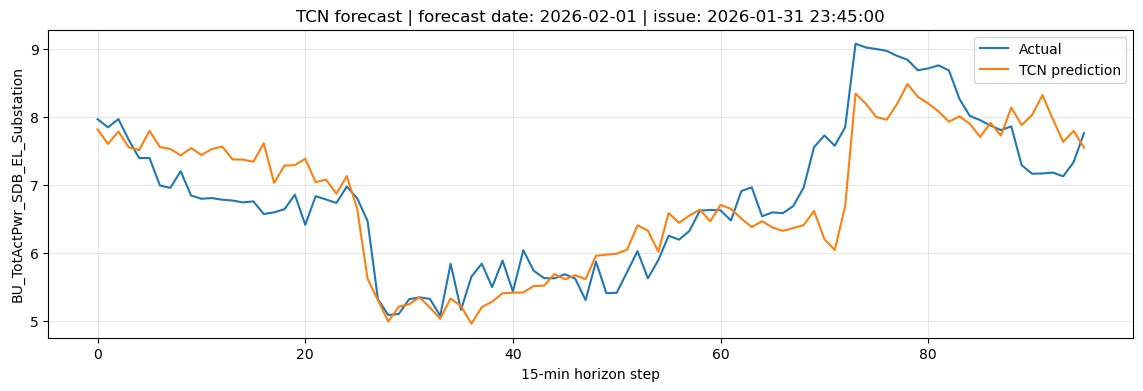

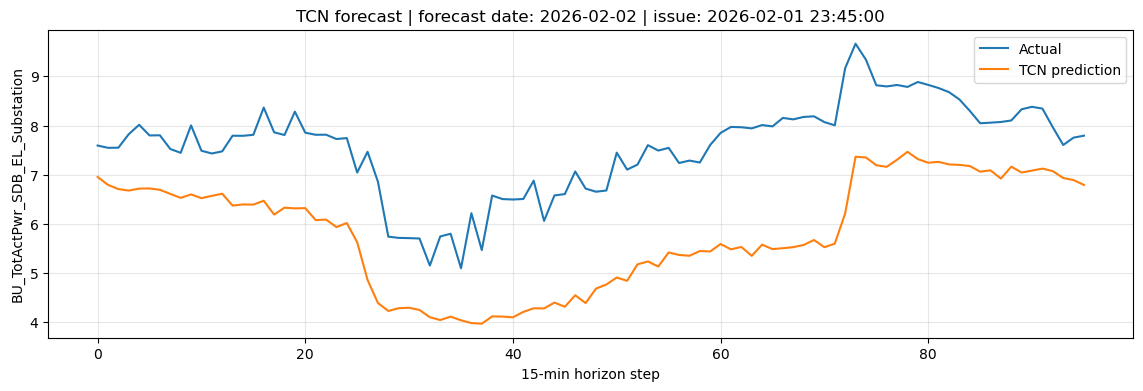

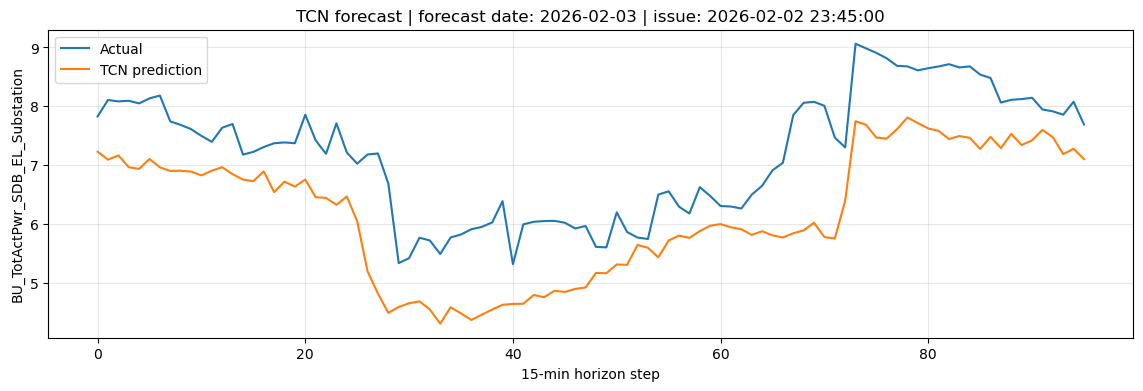

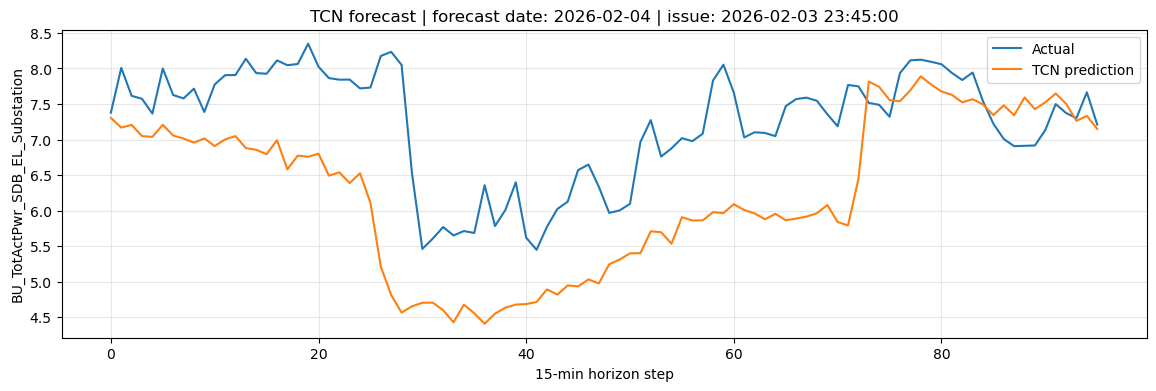

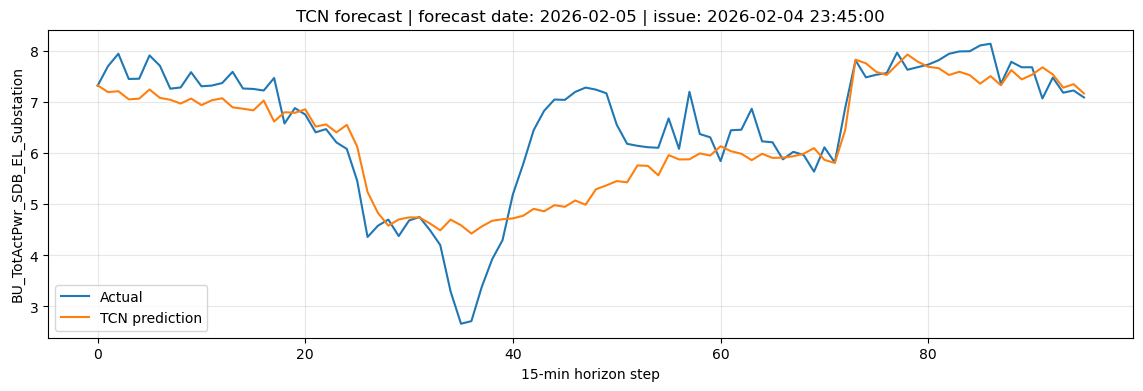

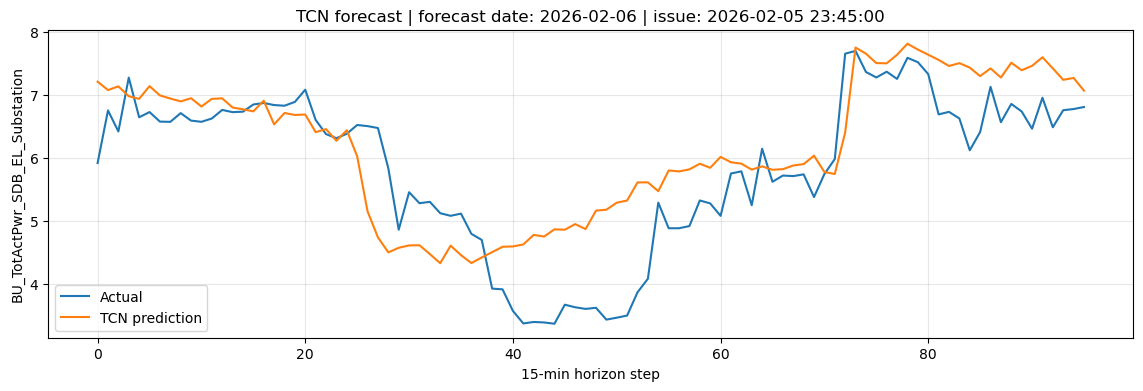

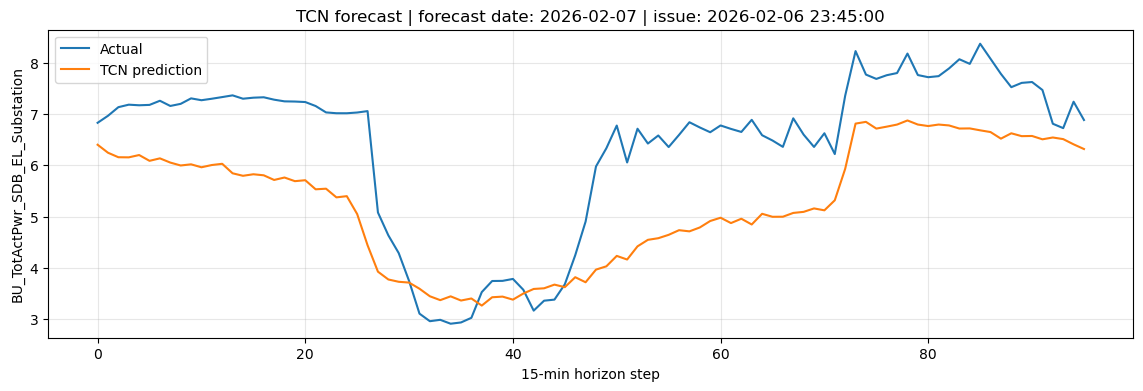

In [325]:
for day_id in range(len(Y_test_raw)):
    plot_tcn_forecast_day(
        day_id,
        Y_test_raw,
        week_test_pred,
        sample_info,
        test_idx,
        target_col,
    )

# old TCN

In [258]:
def build_tcn_day_ahead_sequences(
    df,
    *,
    target_col,
    feature_cols,
    input_steps=288,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_nan=True,
):
    """
    Build TCN samples:
    X shape = [n_samples, input_steps, n_features]
    Y shape = [n_samples, horizon_steps]
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df must have DatetimeIndex")

    data = df.sort_index().copy()

    missing = [c for c in [target_col] + feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Make sure all features are numeric
    data[feature_cols] = data[feature_cols].apply(pd.to_numeric, errors="coerce")
    data[target_col] = pd.to_numeric(data[target_col], errors="coerce")

    issue_mask = (
        (data.index.hour == issue_hour)
        & (data.index.minute == issue_minute)
    )
    issue_times = data.index[issue_mask]

    X_list = []
    Y_list = []
    sample_times = []

    for issue_time in issue_times:
        issue_pos = data.index.get_loc(issue_time)

        start_pos = issue_pos - input_steps + 1
        end_pos = issue_pos + 1

        y_start = issue_pos + 1
        y_end = issue_pos + 1 + horizon_steps

        if start_pos < 0:
            continue

        if y_end > len(data):
            continue

        X_block = data.iloc[start_pos:end_pos][feature_cols].values
        y_block = data.iloc[y_start:y_end][target_col].values

        if drop_nan:
            if np.isnan(X_block).any() or np.isnan(y_block).any():
                continue

        X_list.append(X_block)
        Y_list.append(y_block)
        sample_times.append(issue_time)

    X = np.asarray(X_list, dtype=np.float32)
    Y = np.asarray(Y_list, dtype=np.float32)
    sample_times = pd.DatetimeIndex(sample_times)

    return X, Y, sample_times

In [259]:
input_steps = 288      # 3 days at 15-minute resolution
horizon_steps = 96     # next day at 15-minute resolution

X, Y, sample_times = build_tcn_day_ahead_sequences(
    df_imputed,
    target_col=target_col,
    feature_cols=tcn_feature_cols,
    input_steps=input_steps,
    horizon_steps=horizon_steps,
    issue_hour=23,
    issue_minute=45,
    drop_nan=True,
)

In [260]:
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("First sample:", sample_times.min())
print("Last sample :", sample_times.max())

X shape: (107, 288, 41)
Y shape: (107, 96)
First sample: 2025-10-24 23:45:00
Last sample : 2026-02-07 23:45:00


In [261]:
sample_info = pd.DataFrame({
    "sample_id": np.arange(len(sample_times)),
    "issue_time": sample_times,
})

sample_info["forecast_start"] = sample_info["issue_time"] + pd.Timedelta(minutes=15)
sample_info["forecast_date"] = sample_info["forecast_start"].dt.date

sample_info.tail(20)

,sample_id,issue_time,forecast_start,forecast_date
87,87,2026-01-19 23:45:00,2026-01-20,2026-01-20
88,88,2026-01-20 23:45:00,2026-01-21,2026-01-21
89,89,2026-01-21 23:45:00,2026-01-22,2026-01-22
90,90,2026-01-22 23:45:00,2026-01-23,2026-01-23
91,91,2026-01-23 23:45:00,2026-01-24,2026-01-24
92,92,2026-01-24 23:45:00,2026-01-25,2026-01-25
93,93,2026-01-25 23:45:00,2026-01-26,2026-01-26
94,94,2026-01-26 23:45:00,2026-01-27,2026-01-27
95,95,2026-01-27 23:45:00,2026-01-28,2026-01-28
96,96,2026-01-28 23:45:00,2026-01-29,2026-01-29


In [262]:
test_start = pd.Timestamp("2026-02-01")
test_end = pd.Timestamp("2026-02-08")   # exclusive end

val_start = pd.Timestamp("2026-01-25")
val_end = pd.Timestamp("2026-02-01")    # exclusive end

test_mask = (
    (sample_info["forecast_start"] >= test_start)
    & (sample_info["forecast_start"] < test_end)
)

val_mask = (
    (sample_info["forecast_start"] >= val_start)
    & (sample_info["forecast_start"] < val_end)
)

train_mask = sample_info["forecast_start"] < val_start

train_idx_week = sample_info.loc[train_mask, "sample_id"].values
val_idx_week = sample_info.loc[val_mask, "sample_id"].values
test_idx_week = sample_info.loc[test_mask, "sample_id"].values

print("Train samples:", len(train_idx_week))
print("Val samples:", len(val_idx_week))
print("Test samples:", len(test_idx_week))

print("Train forecast dates:")
print(sample_info.loc[train_mask, "forecast_date"].min(), "to", sample_info.loc[train_mask, "forecast_date"].max())

print("Val forecast dates:")
print(sample_info.loc[val_mask, "forecast_date"].min(), "to", sample_info.loc[val_mask, "forecast_date"].max())

print("Test forecast dates:")
print(sample_info.loc[test_mask, "forecast_date"].min(), "to", sample_info.loc[test_mask, "forecast_date"].max())

Train samples: 92
Val samples: 7
Test samples: 7
Train forecast dates:
2025-10-25 to 2026-01-24
Val forecast dates:
2026-01-25 to 2026-01-31
Test forecast dates:
2026-02-01 to 2026-02-07


In [263]:
def final_holdout_split_indices(n_samples, test_ratio=0.15):
    n_test = max(1, int(round(n_samples * test_ratio)))
    test_start = n_samples - n_test

    trainval_idx = np.arange(0, test_start)
    test_idx = np.arange(test_start, n_samples)

    return trainval_idx, test_idx


def expanding_window_cv_indices(
    trainval_idx,
    *,
    n_folds=3,
    val_size=10,
    gap_size=1,
    min_train_size=30,
):
    """
    Expanding-window CV for daily issue samples.

    gap_size=1 means one forecast issue day gap.
    For day-ahead forecasting, this acts like a 24h gap
    if there is one issue sample per day.
    """

    idx = np.asarray(trainval_idx)
    n = len(idx)

    folds = []

    total_needed = min_train_size + gap_size + n_folds * val_size
    if n < total_needed:
        print(
            f"Warning: small dataset for requested CV. "
            f"n={n}, needed about {total_needed}. Reducing folds may be needed."
        )

    # Validation blocks are placed near the end of trainval
    for fold in range(n_folds):
        val_end = n - (n_folds - 1 - fold) * val_size
        val_start = val_end - val_size

        train_end = val_start - gap_size

        if train_end < min_train_size:
            continue

        train_idx = idx[:train_end]
        val_idx = idx[val_start:val_end]

        folds.append((train_idx, val_idx))

    if not folds:
        raise ValueError(
            "No CV folds created. Reduce n_folds/val_size/gap_size or min_train_size."
        )

    return folds

In [264]:
X_train_raw = X[train_idx_week]
Y_train_raw = Y[train_idx_week]

X_val_raw = X[val_idx_week]
Y_val_raw = Y[val_idx_week]

X_test_raw = X[test_idx_week]
Y_test_raw = Y[test_idx_week]

print("Train:", X_train_raw.shape, Y_train_raw.shape)
print("Val  :", X_val_raw.shape, Y_val_raw.shape)
print("Test :", X_test_raw.shape, Y_test_raw.shape)

Train: (92, 288, 41) (92, 96)
Val  : (7, 288, 41) (7, 96)
Test : (7, 288, 41) (7, 96)


In [265]:
def scale_tcn_data(X_train, Y_train, X_val, Y_val):
    n_train, input_steps, n_features = X_train.shape

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_2d = X_train.reshape(-1, n_features)
    X_val_2d = X_val.reshape(-1, n_features)

    X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
    X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape)

    Y_train_scaled = y_scaler.fit_transform(Y_train)
    Y_val_scaled = y_scaler.transform(Y_val)

    return (
        X_train_scaled.astype(np.float32),
        Y_train_scaled.astype(np.float32),
        X_val_scaled.astype(np.float32),
        Y_val_scaled.astype(np.float32),
        x_scaler,
        y_scaler,
    )


def transform_tcn_data(X, Y, x_scaler, y_scaler):
    n, input_steps, n_features = X.shape

    X_scaled = x_scaler.transform(
        X.reshape(-1, n_features)
    ).reshape(X.shape)

    Y_scaled = y_scaler.transform(Y)

    return X_scaled.astype(np.float32), Y_scaled.astype(np.float32)

In [266]:
class TCNProfileDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].permute(1, 0)
        y = self.Y[idx]
        return x, y

In [267]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(
        self,
        n_inputs,
        n_outputs,
        kernel_size,
        stride,
        dilation,
        padding,
        dropout,
    ):
        super().__init__()

        self.conv1 = nn.Conv1d(
            n_inputs,
            n_outputs,
            kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            n_outputs,
            n_outputs,
            kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1,
            self.chomp1,
            self.relu1,
            self.dropout1,
            self.conv2,
            self.chomp2,
            self.relu2,
            self.dropout2,
        )

        self.downsample = (
            nn.Conv1d(n_inputs, n_outputs, 1)
            if n_inputs != n_outputs
            else None
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        residual = x if self.downsample is None else self.downsample(x)
        return self.relu(out + residual)


class TCNProfileModel(nn.Module):
    def __init__(
        self,
        n_features,
        horizon_steps=96,
        channels=(64, 64, 128),
        kernel_size=3,
        dropout=0.20,
    ):
        super().__init__()

        layers = []

        for i in range(len(channels)):
            dilation_size = 2 ** i
            in_channels = n_features if i == 0 else channels[i - 1]
            out_channels = channels[i]

            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    stride=1,
                    dilation=dilation_size,
                    padding=(kernel_size - 1) * dilation_size,
                    dropout=dropout,
                )
            )

        self.tcn = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.Linear(channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon_steps),
        )

    def forward(self, x):
        z = self.tcn(x)
        z_last = z[:, :, -1]
        out = self.head(z_last)
        return out

In [268]:
class WeightedHuberLoss(nn.Module):
    def __init__(self, horizon_weights, delta=1.0):
        super().__init__()
        self.register_buffer("horizon_weights", horizon_weights)
        self.delta = delta

    def forward(self, pred, target):
        error = pred - target
        abs_error = torch.abs(error)

        quadratic = torch.minimum(
            abs_error,
            torch.tensor(self.delta, device=abs_error.device)
        )
        linear = abs_error - quadratic

        loss = 0.5 * quadratic ** 2 + self.delta * linear

        weighted_loss = loss * self.horizon_weights.view(1, -1)

        return weighted_loss.mean()


def make_horizon_weights(horizon_steps=96):
    weights = np.ones(horizon_steps, dtype=np.float32)

    for i in range(horizon_steps):
        minute = ((i + 1) * 15) % 1440
        hour = minute // 60

        # Focus only on large absolute-error operating period
        if 8 <= hour < 13:
            weights[i] = 1.25

    return torch.tensor(weights, dtype=torch.float32)

In [269]:
def train_tcn_model(
    X_train,
    Y_train,
    X_val,
    Y_val,
    *,
    horizon_steps=96,
    batch_size=128,
    max_epochs=300,
    patience=30,
    learning_rate=0.001,
    weight_decay=1e-4,
    channels=(64, 64, 128),
    kernel_size=3,
    dropout=0.20,
    device="cpu",
):
    train_ds = TCNProfileDataset(X_train, Y_train)
    val_ds = TCNProfileDataset(X_val, Y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    n_features = X_train.shape[2]

    model = TCNProfileModel(
        n_features=n_features,
        horizon_steps=horizon_steps,
        channels=channels,
        kernel_size=kernel_size,
        dropout=dropout,
    ).to(device)

    horizon_weights = make_horizon_weights(horizon_steps).to(device)
    criterion = WeightedHuberLoss(horizon_weights, delta=1.0).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_val_loss = np.inf
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 25 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.5f} | "
                f"val_loss={val_loss:.5f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df


def predict_tcn(model, X_scaled, y_scaler, *, batch_size=32, device="cpu"):
    dummy_y = np.zeros((len(X_scaled), y_scaler.mean_.shape[0]), dtype=np.float32)
    ds = TCNProfileDataset(X_scaled, dummy_y)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    model.eval()
    preds_scaled = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            pred = model(xb).detach().cpu().numpy()
            preds_scaled.append(pred)

    preds_scaled = np.vstack(preds_scaled)
    preds = y_scaler.inverse_transform(preds_scaled)

    return preds

In [270]:
final_val_size = min(10, max(3, int(len(trainval_idx) * 0.15)))
final_gap_size = 1

final_train_idx = trainval_idx[: -(final_val_size + final_gap_size)]
final_val_idx = trainval_idx[-final_val_size:]

X_train_raw = X[final_train_idx]
Y_train_raw = Y[final_train_idx]

X_val_raw = X[final_val_idx]
Y_val_raw = Y[final_val_idx]

X_test_raw = X[test_idx]
Y_test_raw = Y[test_idx]

print("Train:", X_train_raw.shape, Y_train_raw.shape)
print("Val  :", X_val_raw.shape, Y_val_raw.shape)
print("Test :", X_test_raw.shape, Y_test_raw.shape)

Train: (80, 288, 41) (80, 96)
Val  : (10, 288, 41) (10, 96)
Test : (16, 288, 41) (16, 96)


In [271]:
(
    X_train_scaled,
    Y_train_scaled,
    X_val_scaled,
    Y_val_scaled,
    x_scaler,
    y_scaler,
) = scale_tcn_data(
    X_train_raw,
    Y_train_raw,
    X_val_raw,
    Y_val_raw,
)

X_test_scaled, Y_test_scaled = transform_tcn_data(
    X_test_raw,
    Y_test_raw,
    x_scaler,
    y_scaler,
)

In [272]:
week_tcn_model, week_tcn_history = train_tcn_model(
    X_train_scaled,
    Y_train_scaled,
    X_val_scaled,
    Y_val_scaled,
    horizon_steps=horizon_steps,
    batch_size=128,
    max_epochs=300,
    patience=30,
    learning_rate=0.001,
    weight_decay=1e-4,
    channels=(64, 64, 128),
    kernel_size=3,
    dropout=0.20,
    device=device,
)

Epoch 025 | train_loss=0.32999 | val_loss=0.49078
Epoch 050 | train_loss=0.26092 | val_loss=0.46439
Epoch 075 | train_loss=0.21492 | val_loss=0.44859
Early stopping at epoch 92


In [273]:
week_test_pred = predict_tcn(
    week_tcn_model,
    X_test_scaled,
    y_scaler,
    batch_size=32,
    device=device,
)

week_tcn_metrics = evaluate_profile_global(Y_test_raw, week_test_pred)
week_tcn_metrics

{'MAE': 1.9792261123657227,
 'RMSE': 3.3015566304520707,
 'MAPE': 18.34077388048172,
 'sMAPE': 19.013911485671997,
 'R2': 0.8010393977165222}

In [274]:
week_daily_rows = []

for i in range(len(Y_test_raw)):
    y_true_day = Y_test_raw[i].reshape(1, -1)
    y_pred_day = week_test_pred[i].reshape(1, -1)

    metrics = evaluate_profile_global(y_true_day, y_pred_day)

    week_daily_rows.append({
        "day_id": i,
        "issue_time": sample_info.loc[test_idx_week[i], "issue_time"],
        "forecast_date": sample_info.loc[test_idx_week[i], "forecast_date"],
        **metrics,
    })

week_daily_metrics_df = pd.DataFrame(week_daily_rows)
week_daily_metrics_df.sort_values("forecast_date")

IndexError: index 7 is out of bounds for axis 0 with size 7

In [ ]:
sdd

In [ ]:
final_tcn_model_weighted, final_history_weighted = train_tcn_model(
    X_train_scaled,
    Y_train_scaled,
    X_val_scaled,
    Y_val_scaled,
    horizon_steps=horizon_steps,
    batch_size=32,
    max_epochs=300,
    patience=30,
    learning_rate=0.01,
    weight_decay=1e-4,
    channels=(128, 128, 264),
    kernel_size=3,
    dropout=0.20,
    device=device,
)

Epoch 025 | train_loss=0.32017 | val_loss=0.53538
Epoch 050 | train_loss=0.24044 | val_loss=0.54878
Early stopping at epoch 71


In [ ]:
weighted_test_pred = predict_tcn(
    final_tcn_model_weighted,
    X_test_scaled,
    y_scaler,
    batch_size=32,
    device=device,
)

weighted_tcn_metrics = evaluate_profile_global(Y_test_raw, weighted_test_pred)
weighted_tcn_metrics

{'MAE': 1.8915224075317383,
 'RMSE': 3.050100487476374,
 'MAPE': 18.900632858276367,
 'sMAPE': 18.95783692598343,
 'R2': 0.8301920890808105}

In [ ]:
normal_tcn_metrics = {
    "MAE": 2.0518391132354736,
    "RMSE": 3.4522843524340567,
    "MAPE": 18.69504302740097,
    "sMAPE": 19.499556720256805,
    "R2": 0.7824581861495972,
}

comparison_tcn = pd.DataFrame([
    {"model": "normal_TCN", **normal_tcn_metrics},
    {"model": "weighted_TCN", **weighted_tcn_metrics},
])

comparison_tcn

,model,MAE,RMSE,MAPE,sMAPE,R2
0,normal_TCN,2.051839,3.452284,18.695043,19.499557,0.782458
1,weighted_TCN,1.891522,3.050100,18.900633,18.957837,0.830192


In [ ]:
from src.profile_metrics import evaluate_profile_global

daily_rows = []

for i in range(len(Y_test_raw)):
    y_true_day = Y_test_raw[i].reshape(1, -1)
    y_pred_day = test_pred[i].reshape(1, -1)

    metrics = evaluate_profile_global(y_true_day, y_pred_day)

    daily_rows.append({
        "day_id": i,
        "issue_time": sample_times[test_idx[i]],
        "forecast_date": sample_times[test_idx[i]] + pd.Timedelta(days=1),
        **metrics,
    })

daily_metrics_df = pd.DataFrame(daily_rows)

daily_metrics_df.sort_values("MAPE")

,day_id,issue_time,forecast_date,MAE,RMSE,MAPE,sMAPE,R2
0,0,2026-01-23 23:45:00,2026-01-24 23:45:00,0.787743,1.123979,14.099146,13.723399,0.720124
1,1,2026-01-24 23:45:00,2026-01-25 23:45:00,0.909499,1.232093,15.140496,15.168230,0.757383
10,10,2026-02-02 23:45:00,2026-02-03 23:45:00,2.156697,3.577440,16.494374,15.681778,0.871821
5,5,2026-01-28 23:45:00,2026-01-29 23:45:00,1.897875,2.933443,16.512857,17.218535,0.883455
2,2,2026-01-25 23:45:00,2026-01-26 23:45:00,1.640150,2.376644,17.477031,17.281933,0.859357
9,9,2026-02-01 23:45:00,2026-02-02 23:45:00,3.427178,5.710582,18.066637,20.661616,0.719067
13,13,2026-02-05 23:45:00,2026-02-06 23:45:00,1.550641,2.263557,18.214364,19.790404,0.807492
14,14,2026-02-06 23:45:00,2026-02-07 23:45:00,1.191479,1.665103,18.285489,17.813069,0.846138
15,15,2026-02-07 23:45:00,2026-02-08 23:45:00,1.306016,2.057896,18.317576,19.067548,0.603718
8,8,2026-01-31 23:45:00,2026-02-01 23:45:00,1.603504,2.409994,18.509996,18.804479,0.771799


In [ ]:
best_days = daily_metrics_df.sort_values("MAPE").head(5)
worst_days = daily_metrics_df.sort_values("MAPE", ascending=False).head(5)

best_days, worst_days

(    day_id          issue_time       forecast_date       MAE      RMSE  \
 0        0 2026-01-23 23:45:00 2026-01-24 23:45:00  0.787743  1.123979   
 1        1 2026-01-24 23:45:00 2026-01-25 23:45:00  0.909499  1.232093   
 10      10 2026-02-02 23:45:00 2026-02-03 23:45:00  2.156697  3.577440   
 5        5 2026-01-28 23:45:00 2026-01-29 23:45:00  1.897875  2.933443   
 2        2 2026-01-25 23:45:00 2026-01-26 23:45:00  1.640150  2.376644   
 
          MAPE      sMAPE        R2  
 0   14.099146  13.723399  0.720124  
 1   15.140496  15.168230  0.757383  
 10  16.494374  15.681778  0.871821  
 5   16.512857  17.218535  0.883455  
 2   17.477031  17.281933  0.859357  ,
     day_id          issue_time       forecast_date       MAE      RMSE  \
 12      12 2026-02-04 23:45:00 2026-02-05 23:45:00  3.557241  5.471240   
 6        6 2026-01-29 23:45:00 2026-01-30 23:45:00  3.219688  5.034476   
 3        3 2026-01-26 23:45:00 2026-01-27 23:45:00  1.690139  2.300908   
 7        7 2026-01

In [ ]:
import matplotlib.pyplot as plt

def plot_forecast_day(day_id, y_true, y_pred, sample_times, test_idx, target_col):
    plt.figure(figsize=(14, 4))
    plt.plot(y_true[day_id], label="Actual")
    plt.plot(y_pred[day_id], label="Predicted")
    plt.title(
        f"TCN forecast | day_id={day_id} | "
        f"issue={sample_times[test_idx[day_id]]}"
    )
    plt.xlabel("15-min horizon step")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

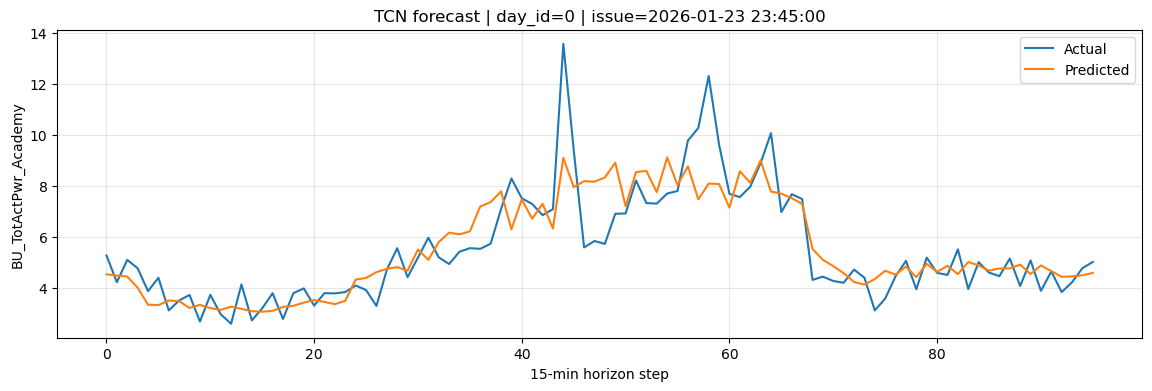

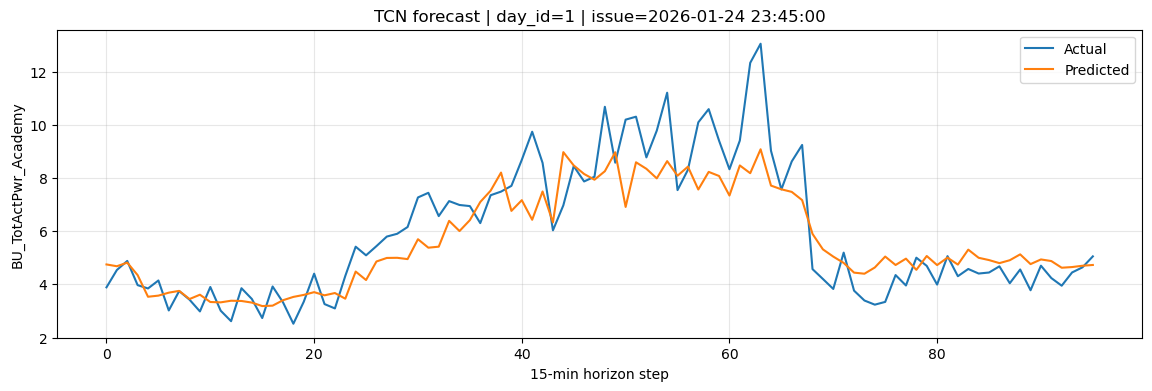

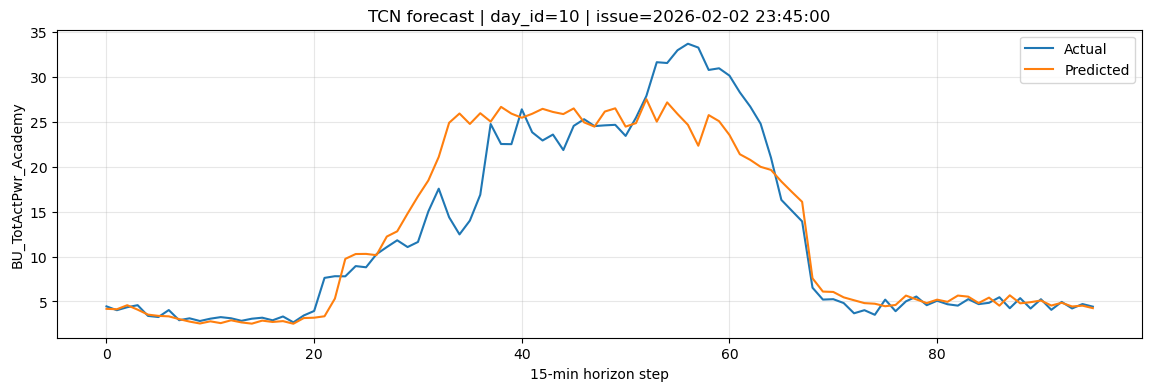

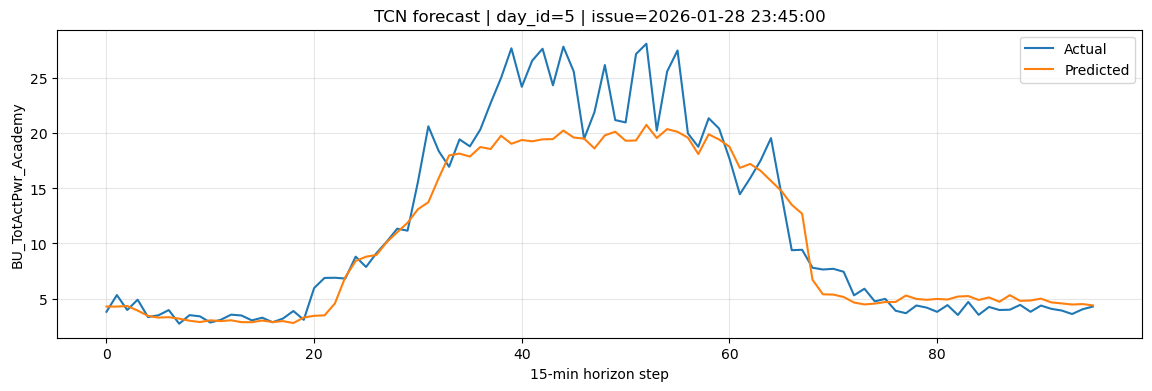

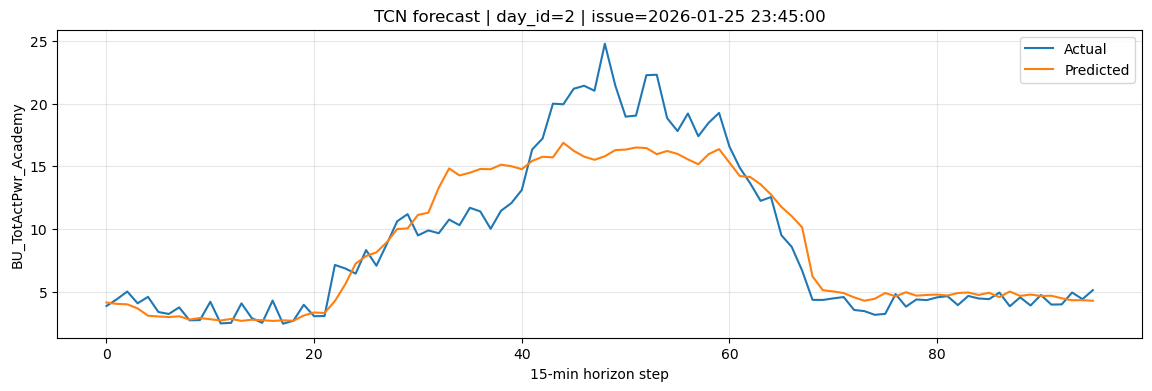

In [ ]:
for day_id in best_days["day_id"]:
    plot_forecast_day(
        day_id,
        Y_test_raw,
        test_pred,
        sample_times,
        test_idx,
        target_col,
    )

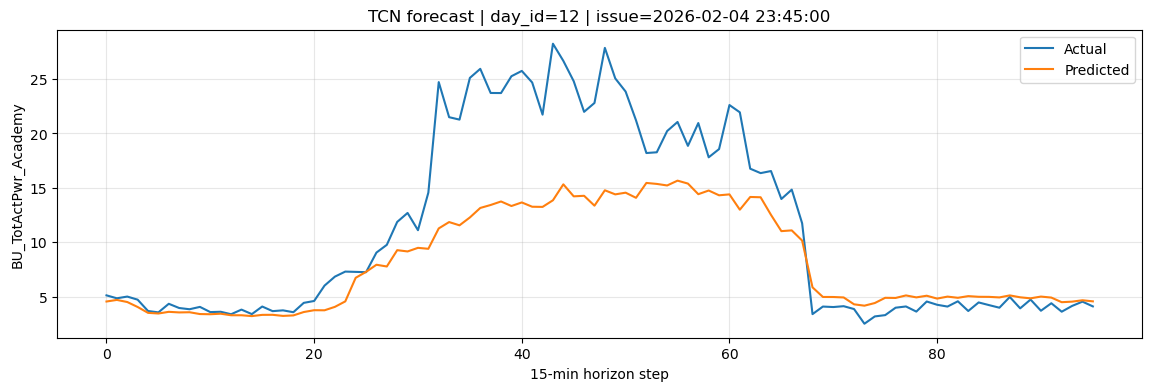

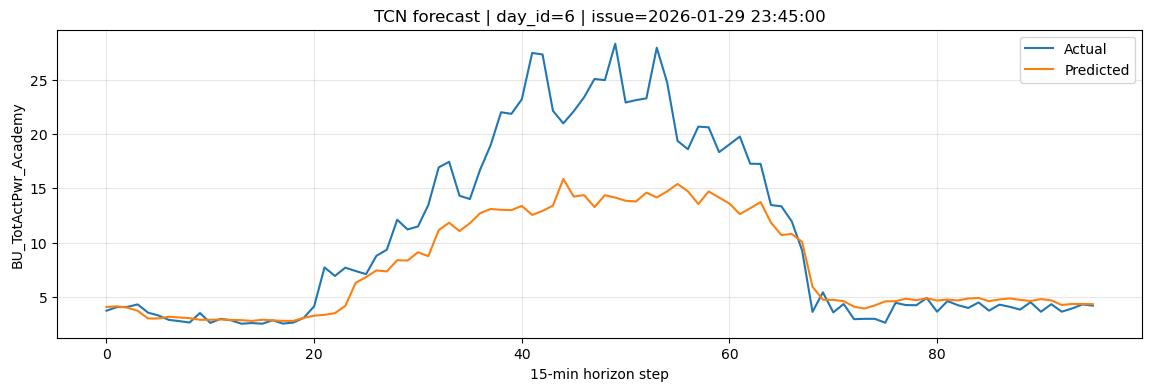

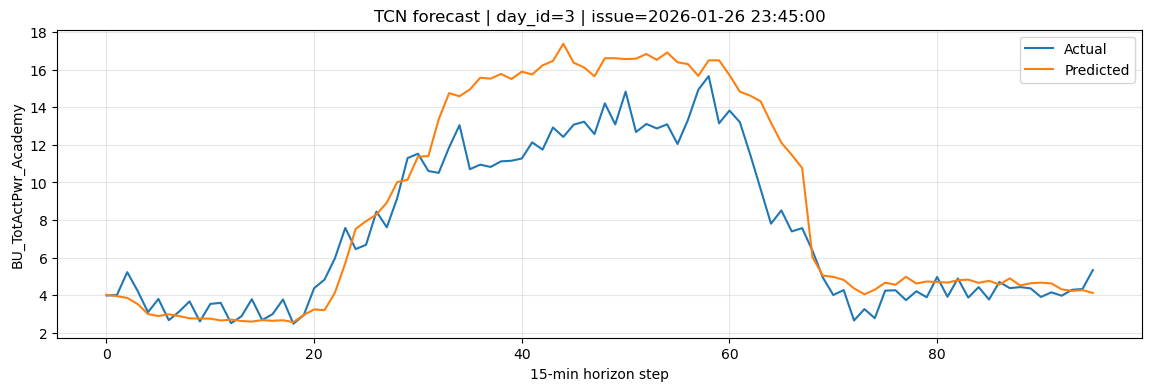

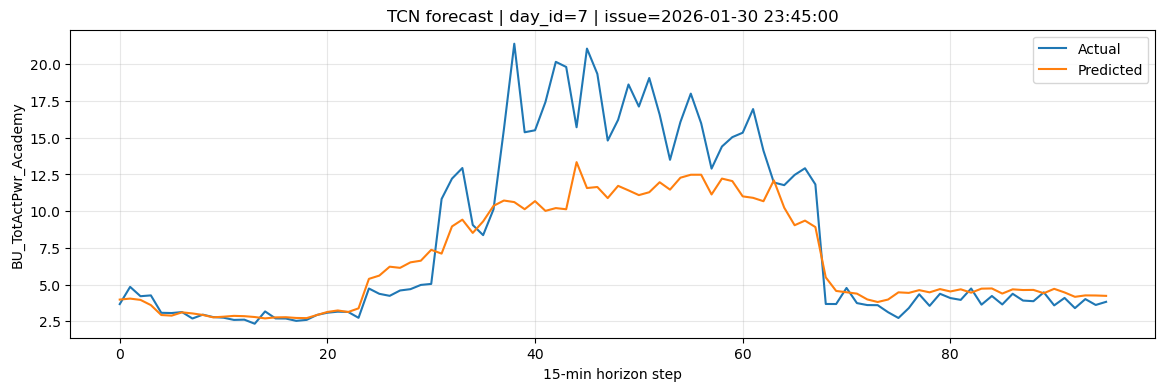

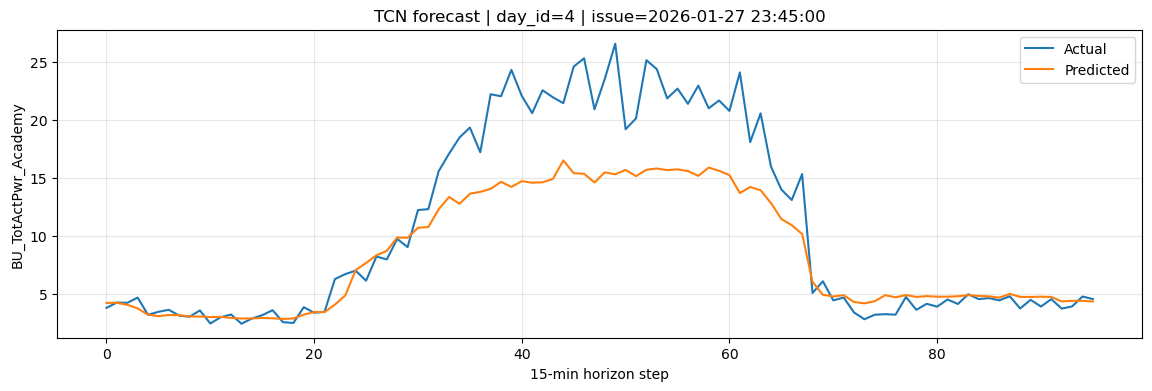

In [ ]:
for day_id in worst_days["day_id"]:
    plot_forecast_day(
        day_id,
        Y_test_raw,
        test_pred,
        sample_times,
        test_idx,
        target_col,
    )

In [ ]:
weighted_horizon_metrics = evaluate_profile_by_horizon(
    Y_test_raw,
    weighted_test_pred
)

weighted_horizon_metrics["minute_of_day"] = (
    weighted_horizon_metrics["horizon_step"] * 15
) % 1440

weighted_horizon_metrics["time_of_day"] = pd.to_datetime(
    weighted_horizon_metrics["minute_of_day"],
    unit="m"
).dt.strftime("%H:%M")

weighted_horizon_metrics.sort_values("MAPE", ascending=False).head(15)

,horizon_step,MAE,RMSE,MAPE,sMAPE,R2,minute_of_day,time_of_day
75,76,1.278184,1.456539,42.466915,32.813370,-2.378365,1140,19:00
74,75,1.080313,1.131630,34.871322,29.120433,-5.171655,1125,18:45
21,22,1.992585,2.611831,31.020141,39.988333,-1.056922,330,05:30
22,23,1.899323,2.161268,30.422887,35.828340,-0.536054,345,05:45
43,44,6.145761,7.265078,29.605684,34.030080,0.200596,660,11:00
67,68,2.936749,3.289217,28.359926,28.288046,-0.291762,1020,17:00
42,43,5.434090,6.330162,28.223103,31.319374,0.308286,645,10:45
68,69,1.225934,1.400474,28.015682,23.341653,-0.363417,1035,17:15
72,73,0.917888,1.144016,27.839959,22.932255,-1.970963,1095,18:15
49,50,5.017807,6.195910,27.532268,29.430664,0.336947,750,12:30


In [ ]:
normal_horizon_metrics = tcn_horizon_metrics.copy()

compare_horizon = normal_horizon_metrics[
    ["horizon_step", "time_of_day", "MAE", "MAPE", "sMAPE", "R2"]
].merge(
    weighted_horizon_metrics[
        ["horizon_step", "MAE", "MAPE", "sMAPE", "R2"]
    ],
    on="horizon_step",
    suffixes=("_normal", "_weighted")
)

compare_horizon["MAE_change"] = (
    compare_horizon["MAE_weighted"] - compare_horizon["MAE_normal"]
)

compare_horizon["MAPE_change"] = (
    compare_horizon["MAPE_weighted"] - compare_horizon["MAPE_normal"]
)

compare_horizon.sort_values("MAPE_normal", ascending=False).head(15)

,horizon_step,time_of_day,MAE_normal,MAPE_normal,sMAPE_normal,R2_normal,MAE_weighted,MAPE_weighted,sMAPE_weighted,R2_weighted,MAE_change,MAPE_change
75,76,19:00,1.285057,42.053097,32.986945,-2.247634,1.278184,42.466915,32.813370,-2.378365,-0.006873,0.413817
74,75,18:45,1.065655,34.382576,28.673637,-5.192712,1.080313,34.871322,29.120433,-5.171655,0.014658,0.488746
22,23,05:45,2.043437,32.083654,39.115876,-0.836702,1.899323,30.422887,35.828340,-0.536054,-0.144114,-1.660767
21,22,05:30,2.003835,30.745375,40.212503,-1.115374,1.992585,31.020141,39.988333,-1.056922,-0.011250,0.274765
67,68,17:00,2.883103,28.475288,28.100169,-0.250499,2.936749,28.359926,28.288046,-0.291762,0.053646,-0.115362
43,44,11:00,6.377550,28.211698,34.311208,0.024363,6.145761,29.605684,34.030080,0.200596,-0.231789,1.393986
33,34,08:30,4.028432,28.139377,28.265527,0.214631,3.458718,25.146616,24.177128,0.318943,-0.569714,-2.992761
49,50,12:30,5.394635,27.417794,30.751896,0.187100,5.017807,27.532268,29.430664,0.336947,-0.376828,0.114474
32,33,08:15,4.254216,27.395815,30.558848,0.232366,3.667001,23.817746,25.677344,0.405174,-0.587216,-3.578068
36,37,09:15,4.035456,27.179950,27.550977,0.234222,3.718545,25.112951,24.091858,0.219488,-0.316911,-2.067000


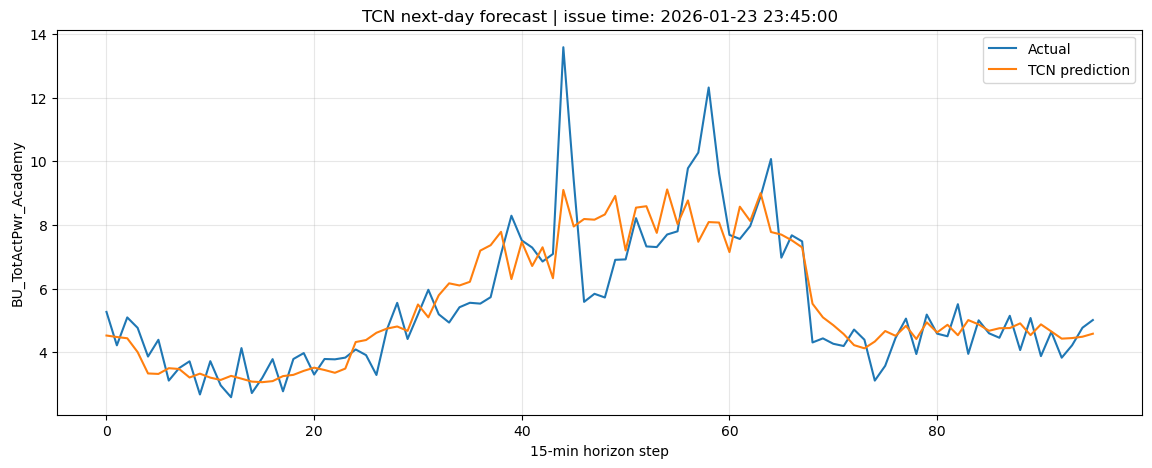

In [ ]:
import matplotlib.pyplot as plt

day_id = 0

plt.figure(figsize=(14, 5))
plt.plot(Y_test_raw[day_id], label="Actual")
plt.plot(test_pred[day_id], label="TCN prediction")
plt.title(f"TCN next-day forecast | issue time: {sample_times[test_idx[day_id]]}")
plt.xlabel("15-min horizon step")
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
tcn_horizon_metrics = evaluate_profile_by_horizon(Y_test_raw, test_pred)
tcn_horizon_metrics[["horizon_step", "MAE", "MAPE", "sMAPE", "R2"]].head()

,horizon_step,MAE,MAPE,sMAPE,R2
0,1,0.373745,8.959866,8.819124,0.137503
1,2,0.312377,7.088047,7.252476,0.127988
2,3,0.424517,9.310279,9.773935,-0.265885
3,4,0.753400,16.375451,18.027584,-4.191393
4,5,0.499932,12.517573,14.130262,-0.985560


In [ ]:
tcn_horizon_metrics.sort_values("MAPE", ascending=False).head(10)

,horizon_step,MAE,RMSE,MAPE,sMAPE,R2
75,76,1.285057,1.428079,42.053097,32.986945,-2.247634
74,75,1.065655,1.133559,34.382576,28.673637,-5.192712
22,23,2.043437,2.363332,32.083654,39.115876,-0.836702
21,22,2.003835,2.648681,30.745375,40.212503,-1.115374
67,68,2.883103,3.236257,28.475288,28.100169,-0.250499
43,44,6.377550,8.026041,28.211698,34.311208,0.024363
33,34,4.028432,5.088694,28.139377,28.265527,0.214631
49,50,5.394635,6.860402,27.417794,30.751896,0.187100
32,33,4.254216,5.337662,27.395815,30.558848,0.232366
36,37,4.035456,5.113216,27.179950,27.550977,0.234222


In [ ]:
tcn_horizon_metrics = evaluate_profile_by_horizon(Y_test_raw, test_pred)

# Convert horizon step to time of day
# If issue time is 23:45, horizon step 1 = 00:00
tcn_horizon_metrics["minute_of_day"] = (
    tcn_horizon_metrics["horizon_step"] * 15
) % 1440

tcn_horizon_metrics["time_of_day"] = pd.to_datetime(
    tcn_horizon_metrics["minute_of_day"],
    unit="m"
).dt.strftime("%H:%M")

tcn_horizon_metrics.sort_values("MAPE", ascending=False).head(15)

,horizon_step,MAE,RMSE,MAPE,sMAPE,R2,minute_of_day,time_of_day
75,76,1.285057,1.428079,42.053097,32.986945,-2.247634,1140,19:00
74,75,1.065655,1.133559,34.382576,28.673637,-5.192712,1125,18:45
22,23,2.043437,2.363332,32.083654,39.115876,-0.836702,345,05:45
21,22,2.003835,2.648681,30.745375,40.212503,-1.115374,330,05:30
67,68,2.883103,3.236257,28.475288,28.100169,-0.250499,1020,17:00
43,44,6.377550,8.026041,28.211698,34.311208,0.024363,660,11:00
33,34,4.028432,5.088694,28.139377,28.265527,0.214631,510,08:30
49,50,5.394635,6.860402,27.417794,30.751896,0.187100,750,12:30
32,33,4.254216,5.337662,27.395815,30.558848,0.232366,495,08:15
36,37,4.035456,5.113216,27.179950,27.550977,0.234222,555,09:15
